In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
import pandas as pd

df = pd.read_csv("Housing.csv")

In [53]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [54]:
df.shape

(545, 13)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [56]:
df.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

In [57]:
df['mainroad'].unique()

array(['yes', 'no'], dtype=object)

In [58]:
df['furnishingstatus'].unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

In [59]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [60]:
df_copy = df.copy()

In [61]:
df_copy['mainroad'] = df_copy['mainroad'].map({
    'yes': 1,
    'no': 0
})

In [62]:
df_copy['mainroad'].unique()

array([1, 0])

In [63]:
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_columns:
    df_copy[col] = df_copy[col].map({
        'yes': 1,
        'no': 0
    })

In [64]:
df_copy.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,NaN,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,NaN,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,NaN,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,NaN,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,NaN,1,1,0,1,2,0,furnished


In [65]:
df_copy = df.copy()

In [66]:
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_columns:
    df_copy[col] = df_copy[col].map({
        'yes': 1,
        'no': 0
    })

In [67]:
df_copy.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [68]:
df_copy['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [69]:
pd.get_dummies(df_copy['furnishingstatus'])

,furnished,semi-furnished,unfurnished
0,True,False,False
1,True,False,False
2,False,True,False
3,True,False,False
4,True,False,False
...,...,...,...
540,False,False,True
541,False,True,False
542,False,False,True
543,True,False,False


In [70]:
df_copy = pd.get_dummies(
    df_copy,
    columns=['furnishingstatus'],
    drop_first=True
)

In [71]:
df_copy.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [72]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    b

In [73]:
X = df_copy.drop('price', axis=1)

y = df_copy['price']

In [74]:
X.shape

(545, 13)

In [75]:
y.shape

(545,)

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [78]:
X_train.shape

(436, 13)

In [79]:
X_test.shape

(109, 13)

In [80]:
y_train.shape

(436,)

In [81]:
y_test.shape

(109,)

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [83]:
X_train.shape

(436, 13)

In [84]:
X_test.shape

(109, 13)

In [85]:
y_train.shape

(436,)

In [86]:
y_test.shape

(109,)

In [87]:
from sklearn.linear_model import LinearRegression

In [88]:
model = LinearRegression()

In [89]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [90]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [91]:
y_pred = model.predict(X_test)

In [92]:
y_pred[:5]

array([5164653.90033968, 7224722.29802167, 3109863.24240338,
       4612075.3272256 , 3294646.25725956])

In [93]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head()

,Actual Price,Predicted Price
316,4060000,5.164654e+06
77,6650000,7.224722e+06
360,3710000,3.109863e+06
90,6440000,4.612075e+06
493,2800000,3.294646e+06


In [94]:
from sklearn.metrics import mean_absolute_error, r2_score

In [95]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 970043.4039201637
R2 Score: 0.6529242642153186


In [96]:
comparison.sample(10)

,Actual Price,Predicted Price
537,1890000,2.755188e+06
255,4480000,4.274731e+06
540,1820000,3.417627e+06
33,8190000,6.796008e+06
360,3710000,3.109863e+06
70,6790000,6.490693e+06
174,5250000,4.727316e+06
486,2870000,3.572362e+06
2,12250000,7.555324e+06
158,5495000,4.566043e+06


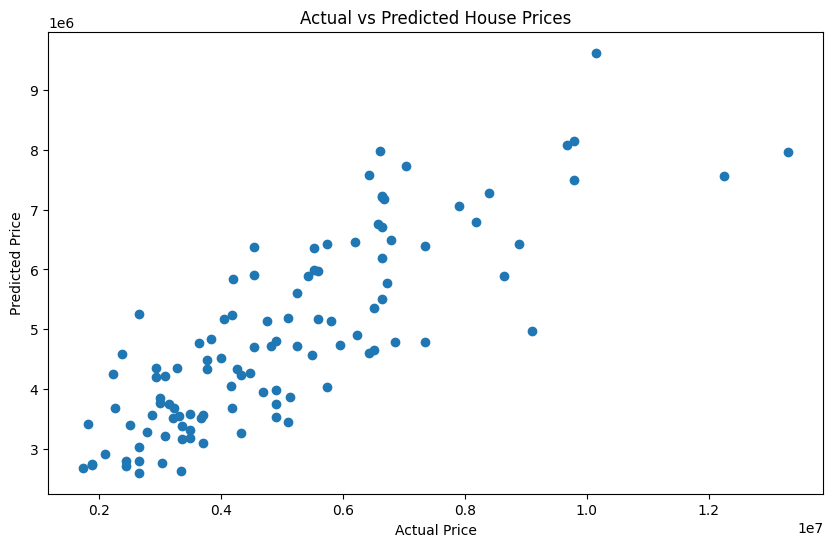

In [97]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

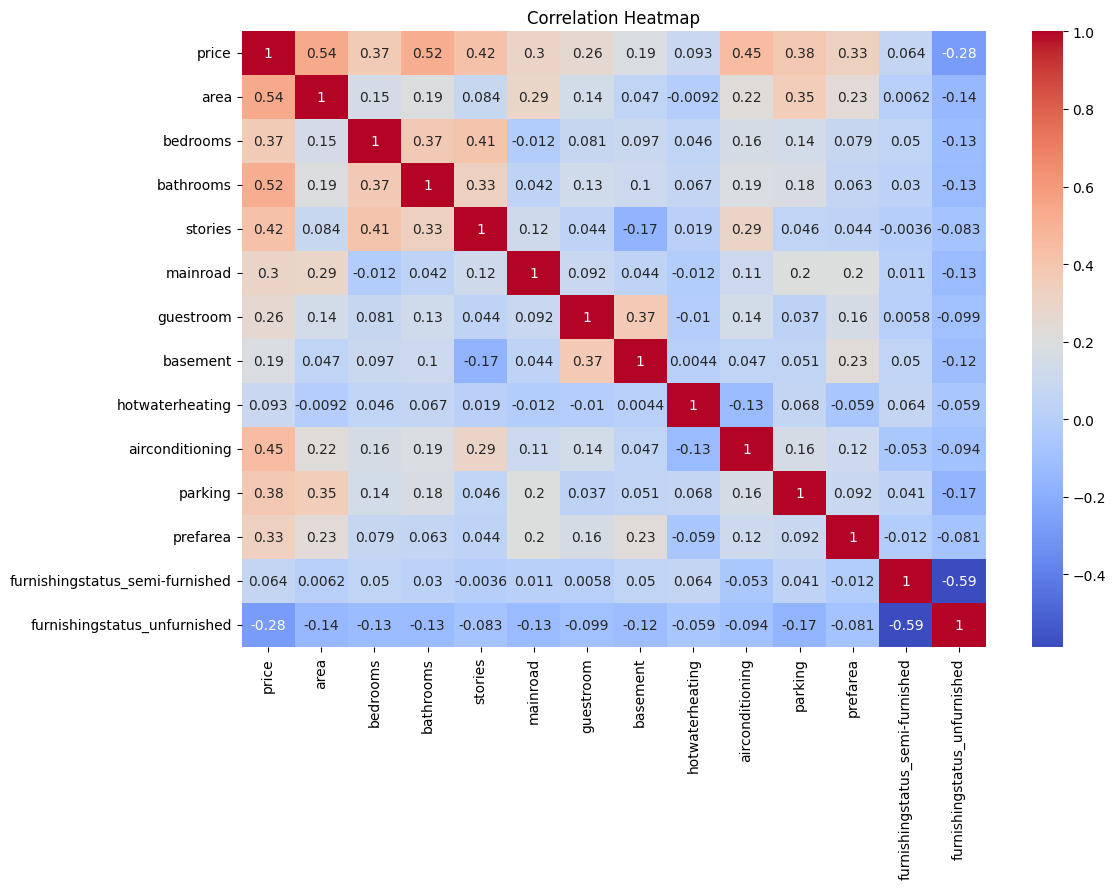

In [98]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_copy.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [99]:
from sklearn.ensemble import RandomForestRegressor

In [100]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [101]:
rf_model

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [102]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [103]:
rf_pred = rf_model.predict(X_test)

In [104]:
rf_pred[:5]

array([5368580.  , 7270270.  , 3751028.75, 4493790.  , 3751650.  ])

In [105]:
from sklearn.metrics import mean_absolute_error, r2_score

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 1022560.0527522935
Random Forest R2 Score: 0.6114024924156645


In [106]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "R2 Score": [r2, rf_r2]
})

results

,Model,MAE,R2 Score
0,Linear Regression,9.700434e+05,0.652924
1,Random Forest,1.022560e+06,0.611402


In [107]:
import pickle

pickle.dump(model, open("house_price_model.pkl", "wb"))